In [1]:
import numpy as np 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib as mpl
import matplotlib.patches as ps
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib.transforms import Bbox
from matplotlib.ticker import FuncFormatter
import torch
import pandas as pd
import torch.nn as nn
import optuna
from models import CondSM
from pathlib import Path
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 9,    # affects horizontal colorbar ticks
    "ytick.labelsize": 9,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 9,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

print(pd.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

def fit_affine_to_target(y_sm: torch.Tensor, y_tgt: torch.Tensor, eps: float = 1e-12, clamp_gain_nonneg: bool = False):
    """
    Fit a,b minimizing ||a*y_sm + b - y_tgt||^2 (least squares with intercept).
    Returns: (a, b, y_aff)
    """
    if not torch.is_tensor(y_sm):
        y_sm = torch.as_tensor(y_sm)
    if not torch.is_tensor(y_tgt):
        y_tgt = torch.as_tensor(y_tgt)
        
    y = y_sm.float().flatten()
    t = y_tgt.float().flatten()

    y_mean = y.mean()
    t_mean = t.mean()

    y0 = y - y_mean
    t0 = t - t_mean

    var_y = (y0 * y0).mean()
    cov_yt = (y0 * t0).mean()

    a = cov_yt / (var_y + eps)
    if clamp_gain_nonneg:
        a = torch.clamp(a, min=0.0)

    b = t_mean - a * y_mean
    y_aff = a * y_sm + b
    return a, b, y_aff

def mse(a, b):
    """Mean squared error between two 1D arrays/tensors."""
    if not torch.is_tensor(a):
        a = torch.as_tensor(a)
    if not torch.is_tensor(b):
        b = torch.as_tensor(b)
    a = a.float().flatten()
    b = b.float().flatten()
    return torch.mean((a - b) ** 2)

2.2.3
cuda


In [24]:
save_path = Path('/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/')

data_type = 'grad_towards_1e7'
func = 'Sine'

input_index = 4
control_indices = [0, 1, 2, 4, 5, 6]
i_scale = 1e21

n = 50
x = torch.linspace(-1.5, 1.5, n)

if func == 'Parabola':
    y_tgt = x ** 2
elif func == 'ReLU':
    m = nn.ReLU()
    y_tgt = m(x)
elif func == 'Sigmoid':
    m = nn.Sigmoid()
    y_tgt = m(4*x)
elif func == 'Cubic':
    y_tgt = x **3
elif func == 'Sine':
    y_tgt = torch.sin(3*x)

def corner_plot_params_scores(
    params,
    scores,
    param_names=None,
    score_name="score",
    cmap="viridis",
    figsize=None,
    s=18,
    alpha=0.85,
    bins=20,
    log_score=False,
    highlight_best=True,
    best_is="min",  # "min" if lower score is better, "max" if higher is better
):
    """
    Corner / pairplot for (N, D) parameters colored by score.

    Parameters
    ----------
    params : array-like, shape (N, D)
        Parameter samples.
    scores : array-like, shape (N,)
        Score for each sample (e.g., KMC simulation score).
    param_names : list[str] or None
        Names for each parameter axis. If None, uses p0..p{D-1}.
    score_name : str
        Label for colorbar.
    cmap : str
        Matplotlib colormap name.
    figsize : tuple or None
        Figure size. If None, chosen automatically from D.
    s : float
        Marker size.
    alpha : float
        Marker transparency.
    bins : int
        Histogram bins for diagonal plots.
    log_score : bool
        If True, colors by log10(scores). Useful if scores span orders of magnitude.
    highlight_best : bool
        If True, draws a red ring around the best-scoring sample.
    best_is : {"min","max"}
        Defines which direction is "best".

    Returns
    -------
    fig, axes : matplotlib Figure and Axes array
    """
    X = np.asarray(params)
    y = np.asarray(scores).reshape(-1)

    if X.ndim != 2:
        raise ValueError(f"params must be 2D (N, D). Got shape {X.shape}")
    if y.shape[0] != X.shape[0]:
        raise ValueError(f"scores length {y.shape[0]} must match N={X.shape[0]}")

    N, D = X.shape
    if param_names is None:
        param_names = [f"p{i}" for i in range(D)]
    if len(param_names) != D:
        raise ValueError(f"param_names must have length D={D}")

    # Color values
    color_vals = np.log10(y) if log_score else y
    color_label = "$\log_{10}(\mathcal{E}_{\mathrm{\sigma}})$" if log_score else score_name

    # Pick best index
    if best_is not in ("min", "max"):
        raise ValueError("best_is must be 'min' or 'max'")
    best_idx = int(np.argmin(y) if best_is == "min" else np.argmax(y))

    # Figure sizing
    if figsize is None:
        # heuristic sizing: ~2.2 inches per dimension
        figsize = (2.2 * D, 2.2 * D)

    fig, axes = plt.subplots(D, D, figsize=figsize, sharex="col", sharey=False)
    fig.subplots_adjust(wspace=0.05, hspace=0.05)

    norm = Normalize(vmin=np.nanmin(color_vals), vmax=np.nanmax(color_vals))
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    for i in range(D):
        for j in range(D):
            ax = axes[i, j]

            if i == j:
                # Diagonal: histogram of parameter j
                ax.hist(X[:, j], bins=bins, density=True)
                if highlight_best:
                    ax.axvline(X[best_idx, j], linewidth=2, c='r')
                ax.tick_params(which='both', left=False, right=False, top=False, bottom=False)
            elif i > j:
                # Lower triangle: scatter (x=j, y=i)
                ax.scatter(
                    X[:, j], X[:, i],
                    c=color_vals, cmap=cmap, norm=norm,
                    s=s, alpha=alpha, linewidths=0
                )
                if highlight_best:
                    ax.scatter(
                        X[best_idx, j], X[best_idx, i],
                        facecolors="none", edgecolors="red",
                        s=s * 3.0, linewidths=2.0, zorder=5
                    )
                ax.minorticks_on()
                ax.tick_params(top=True, right=True, which='both')
                ax.tick_params(direction='in', which='both')
            else:
                # Upper triangle: blank (classic corner style)
                ax.axis("off")

            # Labels only on left column and bottom row
            if i == D - 1 and j <= i:
                ax.set_xlabel(param_names[j])
            else:
                ax.set_xticklabels([])

            if j == 0 and i > 0:
                ax.set_ylabel(param_names[i])
            else:
                if i != D - 1:
                    ax.set_yticklabels([])
            ax.set_yticklabels([])

    # Colorbar
    cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
    cbar.set_label(color_label)

    # Title / annotation
    #best_txt = f"best {score_name}={y[best_idx]:.4g} @ idx {best_idx}"
    #fig.suptitle(best_txt, y=0.995)

    return fig, axes

In [20]:
params = []
fitness_scores = []
gains = []
offsets = []

model_dir = (
    f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/final_datasets/{data_type}/'
    f'sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth'
)
state_dict = torch.load(model_dir, weights_only=False, map_location='cpu')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])
model = model.to(device).eval()

in_range = torch.linspace(-1.5, 1.5, n)
K = 50
for k in range(K):
    npz_path = save_path / f'{data_type}_{func}_topK' / f'random_mse_func_type={func}_data_type={data_type}_topk={k}.npz'
    npz_data = np.load(npz_path)
    full_controls = npz_data['control']
    controls = np.delete(full_controls, [0, input_index])

    control_input = torch.tensor(controls, dtype=torch.float32).expand(n, -1)
    input_tensor = torch.zeros((n, len(controls)+1))
    input_tensor[:, control_indices] = control_input
    input_tensor[:, input_index-1] = in_range
    input_tensor = input_tensor.to(device)
    with torch.no_grad():
        y_sm = model(input_tensor).detach().cpu()
    g_0, p_0, y_aff = fit_affine_to_target(y_sm, y_tgt)

    gains.append(g_0)
    offsets.append(p_0)

    i_out = torch.from_numpy(npz_data['current'] * i_scale)

    fitness = mse(g_0*i_out + p_0, y_tgt)

    params.append(controls)
    fitness_scores.append(fitness)

print(fitness_scores)
print("Gathered data")

[tensor(13.6606), tensor(5.4393), tensor(149.9564), tensor(98.3989), tensor(70.8182), tensor(1.9014), tensor(71.1492), tensor(9.7220), tensor(11.5869), tensor(6.4222), tensor(3.9152), tensor(22.9352), tensor(56.6497), tensor(2.4555), tensor(170.4335), tensor(3.3947), tensor(2.8164), tensor(74.7337), tensor(1.6296), tensor(22.2569), tensor(176.9702), tensor(253.0545), tensor(2.7945), tensor(0.8835), tensor(23.2492), tensor(5.6402), tensor(3.4928), tensor(50.6321), tensor(21.5140), tensor(43.8997), tensor(33.5743), tensor(7.1832), tensor(1.3611), tensor(3.7160), tensor(1.3464), tensor(6.8930), tensor(1.8043), tensor(16.6946), tensor(101.9573), tensor(35.4378), tensor(2.5523), tensor(11.7359), tensor(9.3648), tensor(61.4206), tensor(35.9102), tensor(82.4455), tensor(45.2294), tensor(0.3533), tensor(1.4759), tensor(0.4471)]
Gathered data


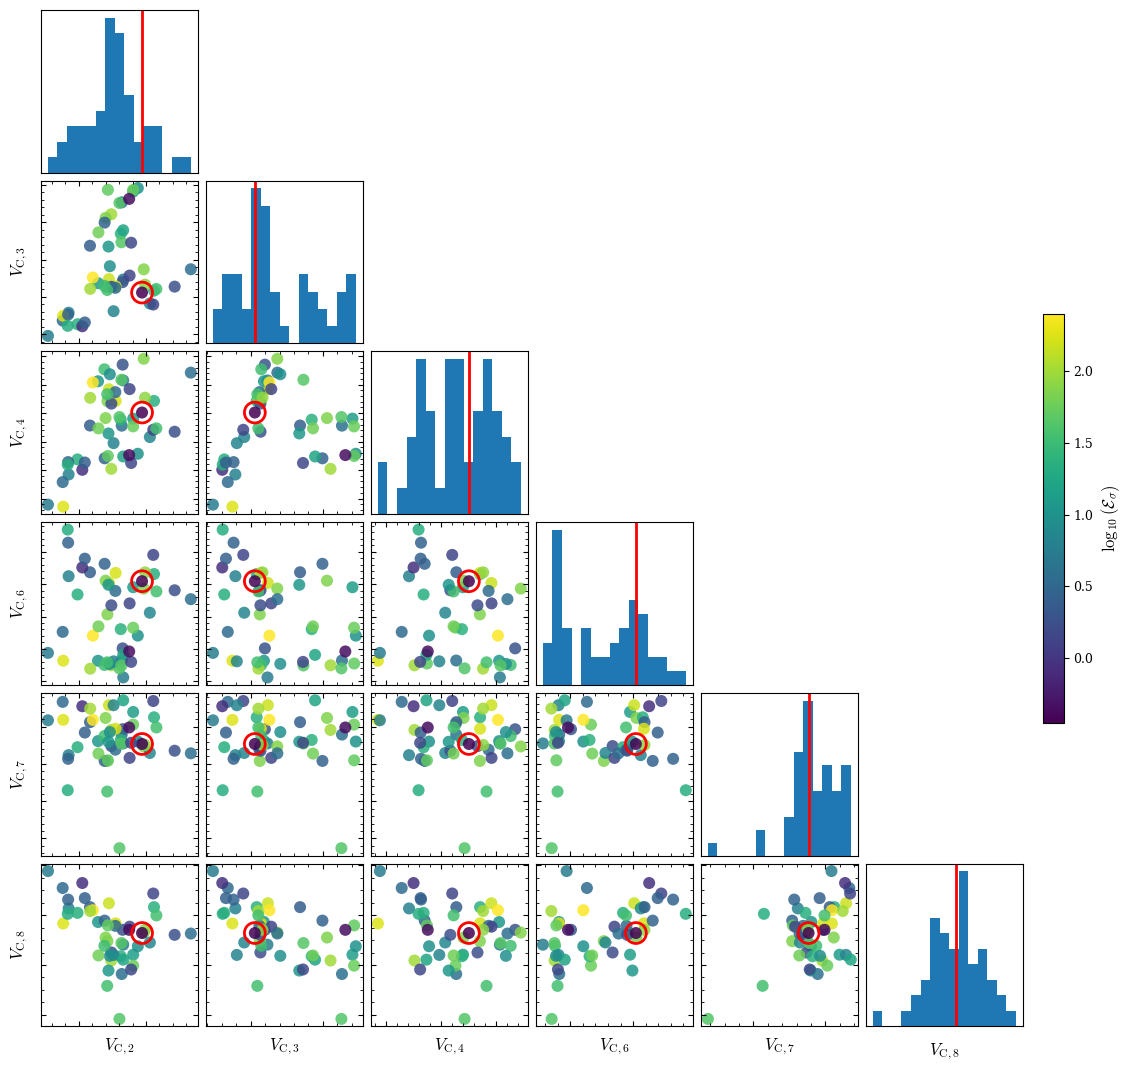

In [25]:
c_labels = [f'$V_{{\mathrm{{C, {i+2}}}}}$' for i in control_indices]

fig, axes = corner_plot_params_scores(
    params=params,
    scores=fitness_scores,
    param_names=c_labels,
    score_name="KMC error",
    best_is="min",          # set "max" if higher score is better
    highlight_best=True,
    log_score=True,
    s=75,
    bins=15
)
plt.show()